# Blinkit Delivery Time Prediction
### Regression Algorithms: Linear, Ridge, Lasso, KNN, SVR

**Goal:** Predict `delivery_time_min` (how many minutes a Blinkit order takes to reach the customer).

**Steps in this notebook**
- Step 1: Import libraries
- Step 2: Load the data
- Step 3: Understand the data
- Step 4: Simple charts
- Step 5: Encoding (OrdinalEncoder and OneHotEncoder)
- Step 6: Train / test split
- Step 7: Scaling
- Step 8: Algorithms, one by one, with accuracy after each
- Step 9: Compare all models

## Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings("ignore")

## Step 2: Load the Data
- File: `blinkit_delivery_data.csv` (1500 orders)
- Keep the CSV and this notebook in the same folder
- In Google Colab, upload the CSV from the Files panel on the left first

In [2]:
df = pd.read_csv("blinkit_delivery_data.csv")
df.head()

,distance_km,items_count,store_prep_min,partner_rating,partner_age,traffic,weather,vehicle,time_of_day,city,delivery_time_min
0,3.58,3,2,3.9,44,Low,Rain,Bike,Evening,Mumbai,18.8
1,2.36,6,4,4.4,36,Medium,Clear,Bike,Night,Mumbai,15.1
2,2.21,11,9,4.6,43,Medium,Fog,Bike,Evening,Delhi,23.9
3,2.21,14,9,3.7,37,Medium,Clear,Cycle,Afternoon,Mumbai,29.2
4,6.51,15,5,4.4,26,Low,Clear,Bike,Afternoon,Bengaluru,27.7


## Step 3: Understand the Data

In [3]:
print("Rows and Columns:", df.shape)

Rows and Columns: (1500, 11)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   distance_km        1500 non-null   float64
 1   items_count        1500 non-null   int64  
 2   store_prep_min     1500 non-null   int64  
 3   partner_rating     1500 non-null   float64
 4   partner_age        1500 non-null   int64  
 5   traffic            1500 non-null   str    
 6   weather            1500 non-null   str    
 7   vehicle            1500 non-null   str    
 8   time_of_day        1500 non-null   str    
 9   city               1500 non-null   str    
 10  delivery_time_min  1500 non-null   float64
dtypes: float64(3), int64(3), str(5)
memory usage: 169.0 KB


In [5]:
df.describe()

,distance_km,items_count,store_prep_min,partner_rating,partner_age,delivery_time_min
count,1500.000000,1500.000000,1500.000000,1500.000000,1500.00000,1500.000000
mean,3.037773,8.219333,6.552667,4.240533,31.67400,22.044067
std,1.834424,4.322771,2.895655,0.433931,7.56566,6.093348
min,0.300000,1.000000,2.000000,3.500000,19.00000,5.000000
25%,1.660000,4.000000,4.000000,3.900000,25.00000,17.700000
50%,2.680000,8.000000,7.000000,4.200000,32.00000,21.800000
75%,3.952500,12.000000,9.000000,4.600000,38.00000,26.000000
max,10.000000,15.000000,11.000000,5.000000,44.00000,43.300000


In [6]:
df.isnull().sum()

distance_km          0
items_count          0
store_prep_min       0
partner_rating       0
partner_age          0
traffic              0
weather              0
vehicle              0
time_of_day          0
city                 0
delivery_time_min    0
dtype: int64

## Step 4: Charts

**Chart 1: How is delivery time spread? (histogram)**

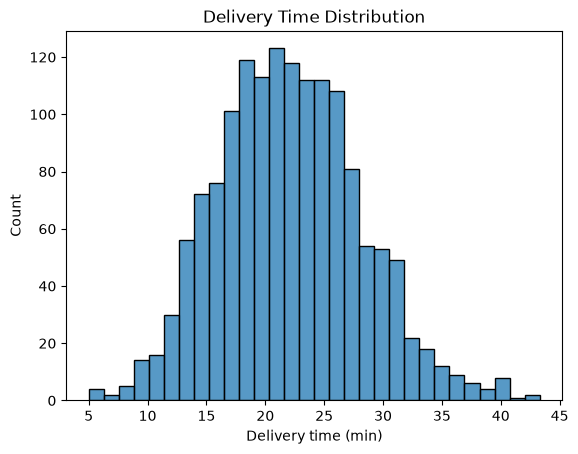

In [7]:
sns.histplot(df["delivery_time_min"], bins=30)
plt.title("Delivery Time Distribution")
plt.xlabel("Delivery time (min)")
plt.show()

**Chart 2: Does distance affect delivery time? (scatter plot)**

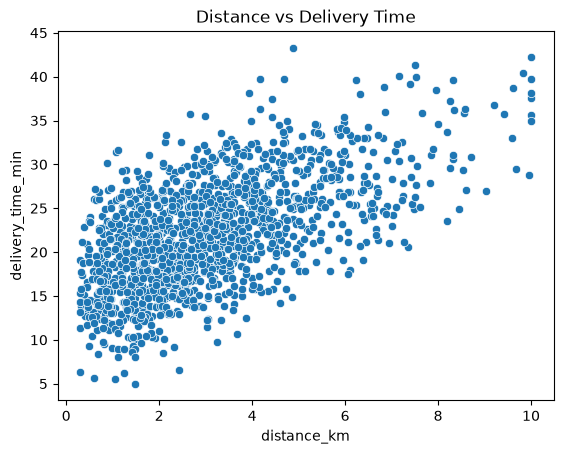

In [8]:
sns.scatterplot(x="distance_km", y="delivery_time_min", data=df)
plt.title("Distance vs Delivery Time")
plt.show()

**Chart 3: Does traffic affect delivery time? (box plot)**

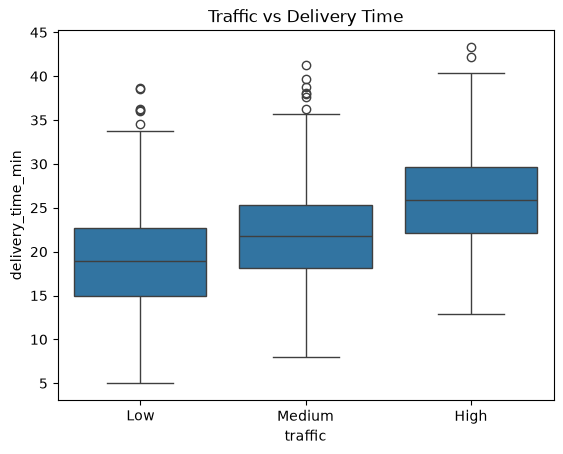

In [9]:
sns.boxplot(x="traffic", y="delivery_time_min", data=df, order=["Low", "Medium", "High"])
plt.title("Traffic vs Delivery Time")
plt.show()

**Chart 4: Average delivery time in each weather (bar plot)**

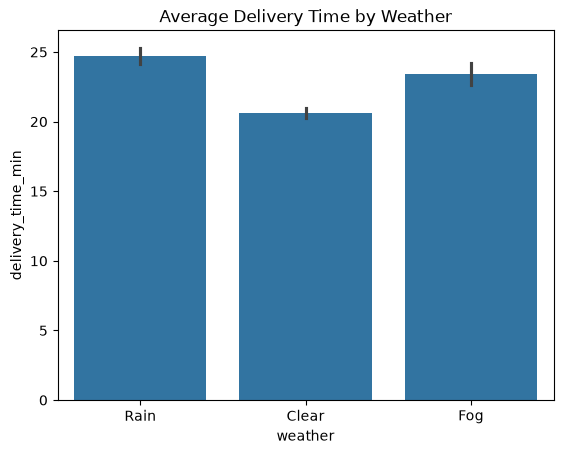

In [10]:
sns.barplot(x="weather", y="delivery_time_min", data=df)
plt.title("Average Delivery Time by Weather")
plt.show()

**Chart 5: Number of orders in each city (count plot)**

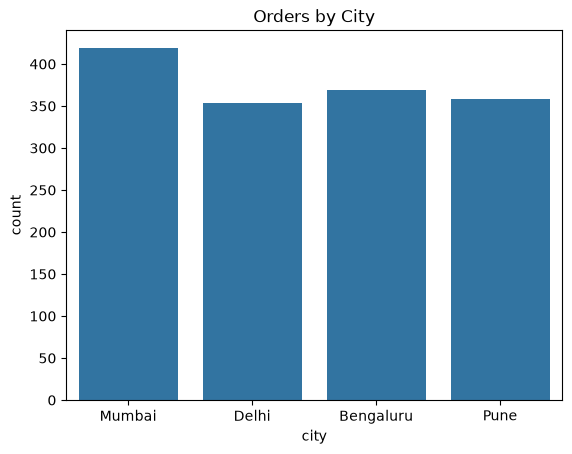

In [11]:
sns.countplot(x="city", data=df)
plt.title("Orders by City")
plt.show()

## Step 5: Encoding
Machine learning models understand only numbers, so we convert the text columns into numbers.

- **OrdinalEncoder**: used when the column has an order. `traffic` is Low < Medium < High, so it becomes 0, 1, 2
- **OneHotEncoder**: used when the column has no order. `weather`, `vehicle`, `time_of_day` and `city` become separate 0/1 columns

**5.1 OrdinalEncoder on `traffic`**

In [12]:
ord_enc = OrdinalEncoder(categories=[["Low", "Medium", "High"]])

traffic_encoded = ord_enc.fit_transform(df[["traffic"]])
traffic_df = pd.DataFrame(traffic_encoded, columns=["traffic"], index=df.index)

traffic_df.head()

,traffic
0,0.0
1,1.0
2,1.0
3,1.0
4,0.0


**5.2 OneHotEncoder on `weather`, `vehicle`, `time_of_day`, `city`**
- `drop="first"` removes one column from each group, because it can be understood from the other columns

In [13]:
ohe_cols = ["weather", "vehicle", "time_of_day", "city"]

ohe = OneHotEncoder(drop="first", sparse_output=False)

ohe_encoded = ohe.fit_transform(df[ohe_cols])
ohe_df = pd.DataFrame(ohe_encoded, columns=ohe.get_feature_names_out(ohe_cols), index=df.index)

ohe_df.head()

,weather_Fog,weather_Rain,vehicle_Cycle,vehicle_Scooter,time_of_day_Evening,time_of_day_Morning,time_of_day_Night,city_Delhi,city_Mumbai,city_Pune
0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**5.3 Join everything to make final X and y**

In [14]:
num_cols = ["distance_km", "items_count", "store_prep_min", "partner_rating", "partner_age"]

X = pd.concat([df[num_cols], traffic_df, ohe_df], axis=1)
y = df["delivery_time_min"]

print("X shape:", X.shape)
X.head()

X shape: (1500, 16)


,distance_km,items_count,store_prep_min,partner_rating,partner_age,traffic,weather_Fog,weather_Rain,vehicle_Cycle,vehicle_Scooter,time_of_day_Evening,time_of_day_Morning,time_of_day_Night,city_Delhi,city_Mumbai,city_Pune
0,3.58,3,2,3.9,44,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2.36,6,4,4.4,36,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
2,2.21,11,9,4.6,43,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,2.21,14,9,3.7,37,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,6.51,15,5,4.4,26,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Step 6: Train Test Split
- 80% data for training, 20% data for testing

In [15]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (1200, 16)
X_test : (300, 16)


## Step 7: Scaling

**What is scaling?**
- Our columns have very different ranges: `distance_km` is 0.3 to 10, `items_count` is 1 to 15, `partner_age` is 19 to 45
- Scaling means bringing all the columns to a similar range, so no column looks "bigger" than others

**Why do we need it?**
- Think of comparing marks of two students: one has 8 out of 10 and the other has 70 out of 100. You cannot compare 8 and 70 directly
- Some algorithms (KNN, SVR, Ridge, Lasso) use the size of the numbers in their calculation, so a column with big numbers will dominate the result
- Scaling gives every column a fair chance

**How does StandardScaler work?**
- Formula: `scaled value = (value - mean) / standard deviation`
- Example: if the average age is 32 and standard deviation is 7, then age 39 becomes (39 - 32) / 7 = 1 and age 25 becomes (25 - 32) / 7 = -1
- After scaling, every column has mean close to 0 and standard deviation close to 1

**How do we apply it in code?**
- `fit_transform` on train data: learns the mean and standard deviation from train data, then applies the formula
- `transform` on test data: uses the same mean and standard deviation from train data. Test data is treated like new unseen data, so we never learn anything from it

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Check:** after scaling, mean is close to 0 and standard deviation is close to 1

In [18]:
scaled_check = pd.DataFrame(X_train_scaled, columns=X.columns)

print("Mean:")
print(scaled_check.mean().round(2))
print()
print("Standard deviation:")
print(scaled_check.std().round(2))

Mean:
distance_km           -0.0
items_count            0.0
store_prep_min        -0.0
partner_rating         0.0
partner_age            0.0
traffic               -0.0
weather_Fog           -0.0
weather_Rain          -0.0
vehicle_Cycle         -0.0
vehicle_Scooter        0.0
time_of_day_Evening   -0.0
time_of_day_Morning    0.0
time_of_day_Night     -0.0
city_Delhi            -0.0
city_Mumbai           -0.0
city_Pune              0.0
dtype: float64

Standard deviation:
distance_km            1.0
items_count            1.0
store_prep_min         1.0
partner_rating         1.0
partner_age            1.0
traffic                1.0
weather_Fog            1.0
weather_Rain           1.0
vehicle_Cycle          1.0
vehicle_Scooter        1.0
time_of_day_Evening    1.0
time_of_day_Morning    1.0
time_of_day_Night      1.0
city_Delhi             1.0
city_Mumbai            1.0
city_Pune              1.0
dtype: float64


## Step 8: Machine Learning Algorithms
For every algorithm we do 2 things:
- Train the model on train data and predict
- Check the accuracy on that model

**Accuracy metrics for regression**
- **MAE**: average error in minutes (lower is better)
- **MSE**: average of squared errors (lower is better)
- **RMSE**: square root of MSE, also in minutes (lower is better)
- **R2 Score**: how much of the delivery time pattern the model explains. 1 is perfect, 0 is bad (higher is better)
- **Train R2 vs Test R2**: if Train R2 is much higher than Test R2, the model is overfitting

### 8.1 Linear Regression
- Fits a straight line (a weighted sum of all columns) to predict the delivery time

In [19]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](16,)","[ 3.72, 1.38, 1.66,..., 0.07,-0.09, 0.03]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,22.15
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,16
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(16)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](16,)","[41.96,41.19,40.6 ,...,27.5 ,19.98,19.07]"


**Accuracy: Linear Regression**

In [20]:
lr_train_pred = lr.predict(X_train_scaled)
lr_test_pred = lr.predict(X_test_scaled)

lr_train_r2 = r2_score(y_train, lr_train_pred)
lr_test_r2 = r2_score(y_test, lr_test_pred)
lr_mae = mean_absolute_error(y_test, lr_test_pred)
lr_mse = mean_squared_error(y_test, lr_test_pred)
lr_rmse = np.sqrt(lr_mse)

print("Linear Regression")
print("Train R2 :", round(lr_train_r2, 4))
print("Test R2  :", round(lr_test_r2, 4))
print("MAE      :", round(lr_mae, 3))
print("MSE      :", round(lr_mse, 3))
print("RMSE     :", round(lr_rmse, 3))

Linear Regression
Train R2 : 0.8897
Test R2  : 0.8843
MAE      : 1.558
MSE      : 3.859
RMSE     : 1.964


**Actual vs Predicted (points close to the red line means good prediction)**

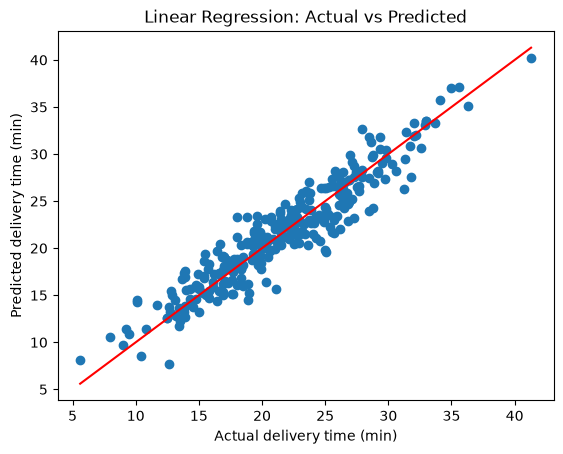

In [21]:
plt.scatter(y_test, lr_test_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.xlabel("Actual delivery time (min)")
plt.ylabel("Predicted delivery time (min)")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

### 8.2 Ridge Regression
- Same as Linear Regression, but it adds a penalty to keep the coefficients small
- `alpha` controls the strength of the penalty. Higher alpha means more shrinking

In [22]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

**Accuracy: Ridge Regression**

In [23]:
ridge_train_pred = ridge.predict(X_train_scaled)
ridge_test_pred = ridge.predict(X_test_scaled)

ridge_train_r2 = r2_score(y_train, ridge_train_pred)
ridge_test_r2 = r2_score(y_test, ridge_test_pred)
ridge_mae = mean_absolute_error(y_test, ridge_test_pred)
ridge_mse = mean_squared_error(y_test, ridge_test_pred)
ridge_rmse = np.sqrt(ridge_mse)

print("Ridge Regression")
print("Train R2 :", round(ridge_train_r2, 4))
print("Test R2  :", round(ridge_test_r2, 4))
print("MAE      :", round(ridge_mae, 3))
print("MSE      :", round(ridge_mse, 3))
print("RMSE     :", round(ridge_rmse, 3))

Ridge Regression
Train R2 : 0.8897
Test R2  : 0.8843
MAE      : 1.558
MSE      : 3.858
RMSE     : 1.964


### 8.3 Lasso Regression
- Also adds a penalty, but it can push the coefficients of useless columns to exactly 0
- So Lasso also works like automatic feature selection

In [24]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",0.1
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


**Accuracy: Lasso Regression**

In [25]:
lasso_train_pred = lasso.predict(X_train_scaled)
lasso_test_pred = lasso.predict(X_test_scaled)

lasso_train_r2 = r2_score(y_train, lasso_train_pred)
lasso_test_r2 = r2_score(y_test, lasso_test_pred)
lasso_mae = mean_absolute_error(y_test, lasso_test_pred)
lasso_mse = mean_squared_error(y_test, lasso_test_pred)
lasso_rmse = np.sqrt(lasso_mse)

print("Lasso Regression")
print("Train R2 :", round(lasso_train_r2, 4))
print("Test R2  :", round(lasso_test_r2, 4))
print("MAE      :", round(lasso_mae, 3))
print("MSE      :", round(lasso_mse, 3))
print("RMSE     :", round(lasso_rmse, 3))

Lasso Regression
Train R2 : 0.8857
Test R2  : 0.8804
MAE      : 1.592
MSE      : 3.986
RMSE     : 1.997


### 8.4 KNN Regressor
- To predict a new order, it finds the 5 most similar orders in train data and takes the average of their delivery times
- `n_neighbors` is the number of similar orders to look at
- Needs scaling because it measures distance between orders

In [26]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


**Accuracy: KNN Regressor**

In [27]:
knn_train_pred = knn.predict(X_train_scaled)
knn_test_pred = knn.predict(X_test_scaled)

knn_train_r2 = r2_score(y_train, knn_train_pred)
knn_test_r2 = r2_score(y_test, knn_test_pred)
knn_mae = mean_absolute_error(y_test, knn_test_pred)
knn_mse = mean_squared_error(y_test, knn_test_pred)
knn_rmse = np.sqrt(knn_mse)

print("KNN Regressor")
print("Train R2 :", round(knn_train_r2, 4))
print("Test R2  :", round(knn_test_r2, 4))
print("MAE      :", round(knn_mae, 3))
print("MSE      :", round(knn_mse, 3))
print("RMSE     :", round(knn_rmse, 3))

KNN Regressor
Train R2 : 0.7361
Test R2  : 0.6102
MAE      : 2.887
MSE      : 12.998
RMSE     : 3.605


### 8.5 SVR (Support Vector Regressor)
- Tries to fit a curve that stays close to most of the data points
- `kernel="rbf"` lets it learn curved (non linear) patterns
- `C` controls how strictly it tries to fit the training data. Higher C can lead to overfitting
- Needs scaling

In [28]:
svr = SVR(kernel="rbf", C=10)
svr.fit(X_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


**Accuracy: SVR**

In [29]:
svr_train_pred = svr.predict(X_train_scaled)
svr_test_pred = svr.predict(X_test_scaled)

svr_train_r2 = r2_score(y_train, svr_train_pred)
svr_test_r2 = r2_score(y_test, svr_test_pred)
svr_mae = mean_absolute_error(y_test, svr_test_pred)
svr_mse = mean_squared_error(y_test, svr_test_pred)
svr_rmse = np.sqrt(svr_mse)

print("SVR")
print("Train R2 :", round(svr_train_r2, 4))
print("Test R2  :", round(svr_test_r2, 4))
print("MAE      :", round(svr_mae, 3))
print("MSE      :", round(svr_mse, 3))
print("RMSE     :", round(svr_rmse, 3))

SVR
Train R2 : 0.9528
Test R2  : 0.8503
MAE      : 1.775
MSE      : 4.993
RMSE     : 2.234


## Step 9: Compare All Models
- Put the accuracy of all 5 models in one table

In [30]:
results_df = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Lasso", "KNN Regressor", "SVR"],
    "Train R2": [lr_train_r2, ridge_train_r2, lasso_train_r2, knn_train_r2, svr_train_r2],
    "Test R2": [lr_test_r2, ridge_test_r2, lasso_test_r2, knn_test_r2, svr_test_r2],
    "MAE": [lr_mae, ridge_mae, lasso_mae, knn_mae, svr_mae],
    "MSE": [lr_mse, ridge_mse, lasso_mse, knn_mse, svr_mse],
    "RMSE": [lr_rmse, ridge_rmse, lasso_rmse, knn_rmse, svr_rmse],
}).round(4)

results_df = results_df.sort_values("Test R2", ascending=False).reset_index(drop=True)
results_df

,Model,Train R2,Test R2,MAE,MSE,RMSE
0,Linear Regression,0.8897,0.8843,1.5583,3.8592,1.9645
1,Ridge,0.8897,0.8843,1.5580,3.8581,1.9642
2,Lasso,0.8857,0.8804,1.5915,3.9864,1.9966
3,SVR,0.9528,0.8503,1.7749,4.9927,2.2344
4,KNN Regressor,0.7361,0.6102,2.8871,12.9976,3.6052


**Test R2 of all models (higher is better)**

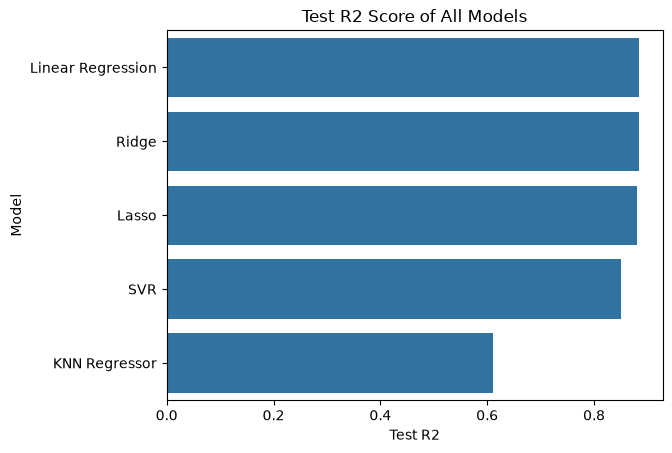

In [31]:
sns.barplot(x="Test R2", y="Model", data=results_df)
plt.title("Test R2 Score of All Models")
plt.show()

**RMSE of all models (lower is better)**

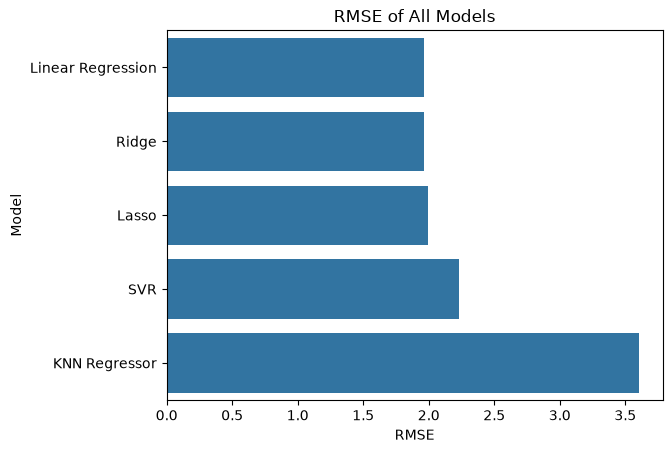

In [32]:
sns.barplot(x="RMSE", y="Model", data=results_df)
plt.title("RMSE of All Models")
plt.show()

## Step 10: Compare Coefficients of Linear, Ridge and Lasso
- Coefficient tells how much each column affects the delivery time
- Look at the Lasso column: some coefficients are exactly 0, so Lasso removed those columns

In [33]:
models = {
    "Linear Regression": lr,
    "Ridge": ridge,
    "Lasso": lasso,
}

coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Linear": models["Linear Regression"].coef_,
    "Ridge": models["Ridge"].coef_,
    "Lasso": models["Lasso"].coef_,
}).round(3)

coef_df

,Feature,Linear,Ridge,Lasso
0,distance_km,3.723,3.720,3.626
1,items_count,1.384,1.383,1.288
2,store_prep_min,1.660,1.658,1.556
3,partner_rating,-0.676,-0.675,-0.578
4,partner_age,-0.062,-0.062,-0.000
5,traffic,2.663,2.661,2.551
6,weather_Fog,0.775,0.774,0.647
7,weather_Rain,1.764,1.762,1.648
8,vehicle_Cycle,1.879,1.877,1.731
9,vehicle_Scooter,0.485,0.484,0.338


In [34]:
print("Columns removed by Lasso (coefficient = 0):")
print(coef_df[coef_df["Lasso"] == 0]["Feature"].tolist())

Columns removed by Lasso (coefficient = 0):
['partner_age', 'city_Delhi', 'city_Pune']


## Summary
- Linear, Ridge and Lasso give good accuracy because delivery time mostly follows a straight line pattern with the columns
- KNN and SVR can learn curved patterns, but they need scaled data
- Always compare Train R2 and Test R2 to check overfitting

## Next Class
- Decision Tree Regressor
- Random Forest Regressor
- XGBoost Regressor

We will use the same `X_train`, `X_test` and `results_df` to compare them with the models above.